In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model

In [85]:
import urllib.request

base_url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/lifesat/"

urllib.request.urlretrieve(
    base_url + "oecd_bli_2015.csv",
    "oecd_bli_2015.csv"
)

urllib.request.urlretrieve(
    base_url + "gdp_per_capita.csv",
    "gdp_per_capita.csv"
)

print("Datasets downloaded!")

Datasets downloaded!


In [86]:
# Dataset Loading
oecd_bli = pd.read_csv("oecd_bli_2015.csv",thousands = ',')
gdp_per_capita = pd.read_csv("gdp_per_capita.csv",thousands =',',delimiter='\t',encoding='latin1',na_values="n/a")

In [87]:
oecd_bli.head()

,LOCATION,Country,INDICATOR,Indicator,MEASURE,Measure,INEQUALITY,Inequality,Unit Code,Unit,PowerCode Code,PowerCode,Reference Period Code,Reference Period,Value,Flag Codes,Flags
0,AUS,Australia,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,1.1,E,Estimated value
1,AUT,Austria,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,1.0,NaN,NaN
2,BEL,Belgium,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,2.0,NaN,NaN
3,CAN,Canada,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,0.2,NaN,NaN
4,CZE,Czech Republic,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,0.9,NaN,NaN


In [88]:
gdp_per_capita.head()

,Country,Subject Descriptor,Units,Scale,Country/Series-specific Notes,2015,Estimates Start After
0,Afghanistan,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",599.994,2013.0
1,Albania,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",3995.383,2010.0
2,Algeria,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",4318.135,2014.0
3,Angola,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",4100.315,2014.0
4,Antigua and Barbuda,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",14414.302,2011.0


In [89]:
oecd_bli.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3292 entries, 0 to 3291
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   LOCATION               3292 non-null   object 
 1   Country                3292 non-null   object 
 2   INDICATOR              3292 non-null   object 
 3   Indicator              3292 non-null   object 
 4   MEASURE                3292 non-null   object 
 5   Measure                3292 non-null   object 
 6   INEQUALITY             3292 non-null   object 
 7   Inequality             3292 non-null   object 
 8   Unit Code              3292 non-null   object 
 9   Unit                   3292 non-null   object 
 10  PowerCode Code         3292 non-null   int64  
 11  PowerCode              3292 non-null   object 
 12  Reference Period Code  0 non-null      float64
 13  Reference Period       0 non-null      float64
 14  Value                  3292 non-null   float64
 15  Flag

In [90]:
gdp_per_capita.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        190 non-null    object 
 1   Subject Descriptor             189 non-null    object 
 2   Units                          189 non-null    object 
 3   Scale                          189 non-null    object 
 4   Country/Series-specific Notes  188 non-null    object 
 5   2015                           187 non-null    float64
 6   Estimates Start After          188 non-null    float64
dtypes: float64(2), object(5)
memory usage: 10.5+ KB


In [91]:
oecd_bli.describe()

,PowerCode Code,Reference Period Code,Reference Period,Value
count,3292.0,0.0,0.0,3292.000000
mean,0.0,NaN,NaN,4774.392587
std,0.0,NaN,NaN,13941.537833
min,0.0,NaN,NaN,0.000000
25%,0.0,NaN,NaN,6.600000
50%,0.0,NaN,NaN,49.000000
75%,0.0,NaN,NaN,90.000000
max,0.0,NaN,NaN,145769.000000


In [92]:
gdp_per_capita.describe()

,2015,Estimates Start After
count,187.000000,188.000000
mean,12590.961401,1969.250000
std,17387.035890,291.147823
min,220.860000,0.000000
25%,1783.538000,2011.000000
50%,5373.633000,2013.000000
75%,15490.576500,2014.000000
max,101994.093000,2015.000000


In [93]:
oecd_bli.isnull().sum()

,0
LOCATION,0
Country,0
INDICATOR,0
Indicator,0
MEASURE,0
Measure,0
INEQUALITY,0
Inequality,0
Unit Code,0
Unit,0


In [94]:
gdp_per_capita.isnull().sum()

,0
Country,0
Subject Descriptor,1
Units,1
Scale,1
Country/Series-specific Notes,2
2015,3
Estimates Start After,2


In [95]:
oecd_bli.sample(5)

,LOCATION,Country,INDICATOR,Indicator,MEASURE,Measure,INEQUALITY,Inequality,Unit Code,Unit,PowerCode Code,PowerCode,Reference Period Code,Reference Period,Value,Flag Codes,Flags
497,ESP,Spain,IW_HADI,Household net adjusted disposable income,L,Value,LW,Low,USD,US Dollar,0,units,NaN,NaN,6791.0,E,Estimated value
1883,ESP,Spain,EQ_AIRP,Air pollution,L,Value,TOT,Total,MICRO_M3,Micrograms per cubic metre,0,units,NaN,NaN,24.0,NaN,NaN
1721,HUN,Hungary,ES_STCS,Student skills,L,Value,LW,Low,AVSCORE,Average score,0,units,NaN,NaN,428.0,NaN,NaN
225,FRA,France,HO_NUMR,Rooms per person,L,Value,TOT,Total,RATIO,Ratio,0,units,NaN,NaN,1.8,NaN,NaN
1293,DEU,Germany,SC_SNTWS,Quality of support network,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,94.0,NaN,NaN


In [96]:
gdp_per_capita.sample(5)

,Country,Subject Descriptor,Units,Scale,Country/Series-specific Notes,2015,Estimates Start After
135,Qatar,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",76576.080,2014.0
32,Chad,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",941.903,2004.0
87,Korea,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",27195.197,2014.0
15,Belgium,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",40106.632,2014.0
46,Dominica,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",7030.145,2011.0


In [97]:
oecd_bli.columns

Index(['LOCATION', 'Country', 'INDICATOR', 'Indicator', 'MEASURE', 'Measure',
       'INEQUALITY', 'Inequality', 'Unit Code', 'Unit', 'PowerCode Code',
       'PowerCode', 'Reference Period Code', 'Reference Period', 'Value',
       'Flag Codes', 'Flags'],
      dtype='object')

In [98]:
oecd_bli["Country"].unique()

array(['Australia', 'Austria', 'Belgium', 'Canada', 'Czech Republic',
       'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Hungary',
       'Iceland', 'Ireland', 'Italy', 'Japan', 'Korea', 'Luxembourg',
       'Mexico', 'Netherlands', 'New Zealand', 'Norway', 'Poland',
       'Portugal', 'Slovak Republic', 'Spain', 'Sweden', 'Switzerland',
       'Turkey', 'United Kingdom', 'United States', 'Brazil', 'Chile',
       'Estonia', 'Israel', 'Russia', 'Slovenia', 'OECD - Total'],
      dtype=object)

In [99]:
oecd_bli["Indicator"].unique()

array(['Dwellings without basic facilities', 'Housing expenditure',
       'Rooms per person', 'Household net adjusted disposable income',
       'Household net financial wealth', 'Employment rate',
       'Job security', 'Long-term unemployment rate', 'Personal earnings',
       'Quality of support network', 'Educational attainment',
       'Student skills', 'Years in education', 'Air pollution',
       'Water quality', 'Consultation on rule-making', 'Voter turnout',
       'Life expectancy', 'Self-reported health', 'Life satisfaction',
       'Assault rate', 'Homicide rate',
       'Employees working very long hours',
       'Time devoted to leisure and personal care'], dtype=object)

In [100]:
oecd_bli.shape

(3292, 17)

In [101]:
gdp_per_capita.columns

Index(['Country', 'Subject Descriptor', 'Units', 'Scale',
       'Country/Series-specific Notes', '2015', 'Estimates Start After'],
      dtype='object')

In [102]:
gdp_per_capita.shape

(190, 7)

In [103]:
oecd_bli.duplicated().sum()

np.int64(0)

In [104]:
gdp_per_capita.duplicated().sum()

np.int64(0)

In [105]:
def prepare_country_stats(oecd_bli, gdp_per_capita):

    life = oecd_bli[
        (oecd_bli["Indicator"] == "Life satisfaction") &
        (oecd_bli["INEQUALITY"] == "TOT")
    ][["Country", "Value"]]


    life = life.rename(
        columns={"Value": "Life satisfaction"}
    )


    gdp = gdp_per_capita[["Country", "2015"]].copy()


    gdp["2015"] = pd.to_numeric(
        gdp["2015"],
        errors="coerce"
    )

    # Rename
    gdp = gdp.rename(
        columns={"2015": "GDP per capita"}
    )


    country_stats = pd.merge(
        life,
        gdp,
        on="Country",
        how="inner"
    )

    # Missing value remove
    country_stats = country_stats.dropna()

    return country_stats

In [106]:
#Prepare the data
country_stats = prepare_country_stats(oecd_bli,gdp_per_capita)
X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]

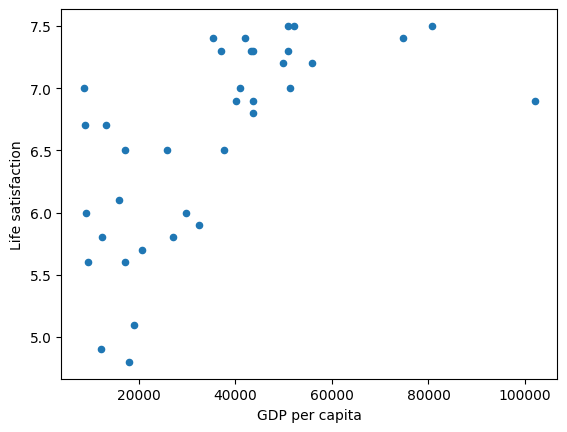

In [107]:
#visualize the data
country_stats.plot(kind='scatter',x="GDP per capita",y="Life satisfaction")
plt.show()

In [108]:
#linear model selection
model = sklearn.linear_model.LinearRegression()


In [109]:
#Train the model
model.fit(X,y)

LinearRegression()

In [110]:
#Make prediction
X_new = [[22587]]
prediction = model.predict(X_new)
print(prediction)

[[6.28653637]]


In [111]:
import sklearn.neighbors
model1 = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3)

In [112]:
model1.fit(X,y)

KNeighborsRegressor(n_neighbors=3)

In [113]:
X_new = [[22587]]
prediction = model1.predict(X_new)
print(prediction)

[[5.76666667]]
